## Program: TKEmodel
### Fit TKE, sig_w, and dissipation data into the model.

### Histories:
### 2024/10/04 -- Bicheng Chen (bchen@xmu.edu.cn) -- First created.

## 
---
---
## Prerequisite Module

In [1]:
import os
import pandas as pd
import numpy as np
from fractions import Fraction
from model.lsclib import caseClass, find_caseKey
from scipy import linalg
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import math

## 
---
---
## User-specified Variable

In [2]:
# File
path_data = "G:/LSCDynRegime_cxy/data"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

In [3]:
# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
κ = 0.012 # for tke32, kappa = 0.022 is the best
# κ = 0.01 # for w3
"""
ustar (m/s)  kH
0.01214      2.5/nan
0.00857      5.0
0.00605      10.0
"""

'\nustar (m/s)  kH\n0.01214      2.5/nan\n0.00857      5.0\n0.00605      10.0\n'

In [4]:
# Data
key_col = ["cov_ww+", "tke+", "P+", "dissip+"]
nz = 101
H = 25 # m
Δt = 120 # second
dz_nd = 1 / (nz - 1)

##
---
---
### User-defined Function

In [5]:
# Calculate the first independent variable of the fitting formula
def cal_xs(χ):
    return 1+1/χ**3

In [6]:
# Calculate the second independent variable of the fitting formula
def cal_xl(Laₜ, χ, kH):
    if Laₜ == np.inf:
        xl = (1+1/χ**3)
    else:
        #xl = (1+1/χ**3)*np.sqrt((1+Laₜ**2)/(Laₜ**2+2*κ*kH)) # kappa=0.022
        xl = (1+1/χ**3)*np.sqrt((1+Laₜ)/(Laₜ+2*κ*kH)) # kappa=0.012
        #xl = (1+1/χ**3)*np.sqrt((1+Laₜ)/(Laₜ)) # kappa=0.012
        #xl = (1+1/χ**3)*(1+(1+1/χ**3)*Laₜ**2)/(2*κ*kH+(1+1/χ**3)*Laₜ**2)
        #xl = (1+1/χ**3)*np.sqrt((1/(2*κ*kH)+Laₜ)/(Laₜ+1))
        #xl = (1+1/χ**3)*(1/np.sqrt(2*κ*kH)+Laₜ**2)/(1+Laₜ**2)
    return xl


## 
---
---
### Read TKE data for each case

In [7]:
## Create case containers
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all[case.key_case] = case
            case_all[case.key_case].xs = cal_xs(χ)
            case_all[case.key_case].xl = cal_xl(Laₜ, χ, kH)
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case
                case_all[case.key_case].xs = cal_xs(χ)
                case_all[case.key_case].xl = cal_xl(Laₜ, χ, kH)

In [8]:
## Read all data
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for case in case_all:
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['w3+'] = data_col['cov_ww+']
    case_all[case].data['P+'] = data_col['P+']
    case_all[case].data['tke2+_nut'] = data_col['tke+']
    case_all[case].data['dissip+_nut'] = data_col['dissip+']
    case_all[case].data['tke32+_les_H'] = data_col['tke+']
    case_all[case].data['tke32+'] = data_col['tke+'][50]
    case_all[case].data['dissip+'] = data_col['dissip+'][50]

    case_all[case].data = case_all[case].data.mean()
    case_all[case].data['tke32+_les_H'] **= 3/2
    case_all[case].data['tke2+_nut'] **= 2
    case_all[case].data['tke32+'] **= 3/2
    case_all[case].data['w3+'] **= 3/2

##
---
---
### Fitting data to derived models

In [9]:
## Re-organize data to array-type for fitting
# Declare data variable
ndim = len(case_all)
xs_les = np.zeros(ndim)
xl_les = np.zeros(ndim)
tke32_les = np.zeros(ndim)
w3_les = np.zeros(ndim)
dissip_les = np.zeros(ndim)

nu_t_les = np.zeros(ndim)
tke32_les_H= np.zeros(ndim)

# Extract data values from data containers
for ic, case in enumerate(case_all):
    xs_les[ic] = case_all[case].xs
    xl_les[ic] = case_all[case].xl
    tke32_les[ic] = case_all[case].data['tke32+']
    w3_les[ic] = case_all[case].data['w3+']
    dissip_les[ic] = case_all[case].data['dissip+']
    nu_t_les[ic] = 0.09*case_all[case].data['tke2+_nut']/case_all[case].data['dissip+_nut']
    tke32_les_H[ic] = case_all[case].data['tke32+_les_H']
    

In [10]:
## Do the linear fit for TKE model
mat = xl_les[:, np.newaxis]
coef_tke32, resid, rank, sigma = linalg.lstsq(mat, tke32_les)

SStot = ((tke32_les - tke32_les.mean())**2).sum()
SSres = ((tke32_les - np.dot(mat,coef_tke32))**2).sum()
R2_tke32 = 1 - SSres / SStot

In [11]:
coef_tke32

array([2.36618114])

In [12]:
R2_tke32

np.float64(0.9379721505799723)

In [13]:
## Do the linear fit for w3 model
mat = xl_les[:, np.newaxis]
#mat = np.hstack([np.ones(xl_les[:, np.newaxis].shape), xl_les[:, np.newaxis]])
coef_w3, resid, rank, sigma = linalg.lstsq(mat, w3_les)

SStot = ((w3_les - w3_les.mean())**2).sum()
SSres = ((w3_les - np.dot(mat,coef_w3))**2).sum()
R2_w3 = 1 - SSres / SStot

In [14]:
coef_w3

array([0.44011534])

In [15]:
R2_w3

np.float64(0.7076102343251989)

In [16]:
## Do the linear fit for dissipation model
mat = xs_les[:, np.newaxis]
coef_dissip, resid, rank, sigma = linalg.lstsq(mat, dissip_les)

SStot = ((dissip_les - dissip_les.mean())**2).sum()
SSres = ((dissip_les - np.dot(mat,coef_dissip))**2).sum()
R2_dissip = 1 - SSres / SStot

In [17]:
coef_dissip

array([2.70190431])

In [18]:
R2_dissip

np.float64(0.946088164015351)

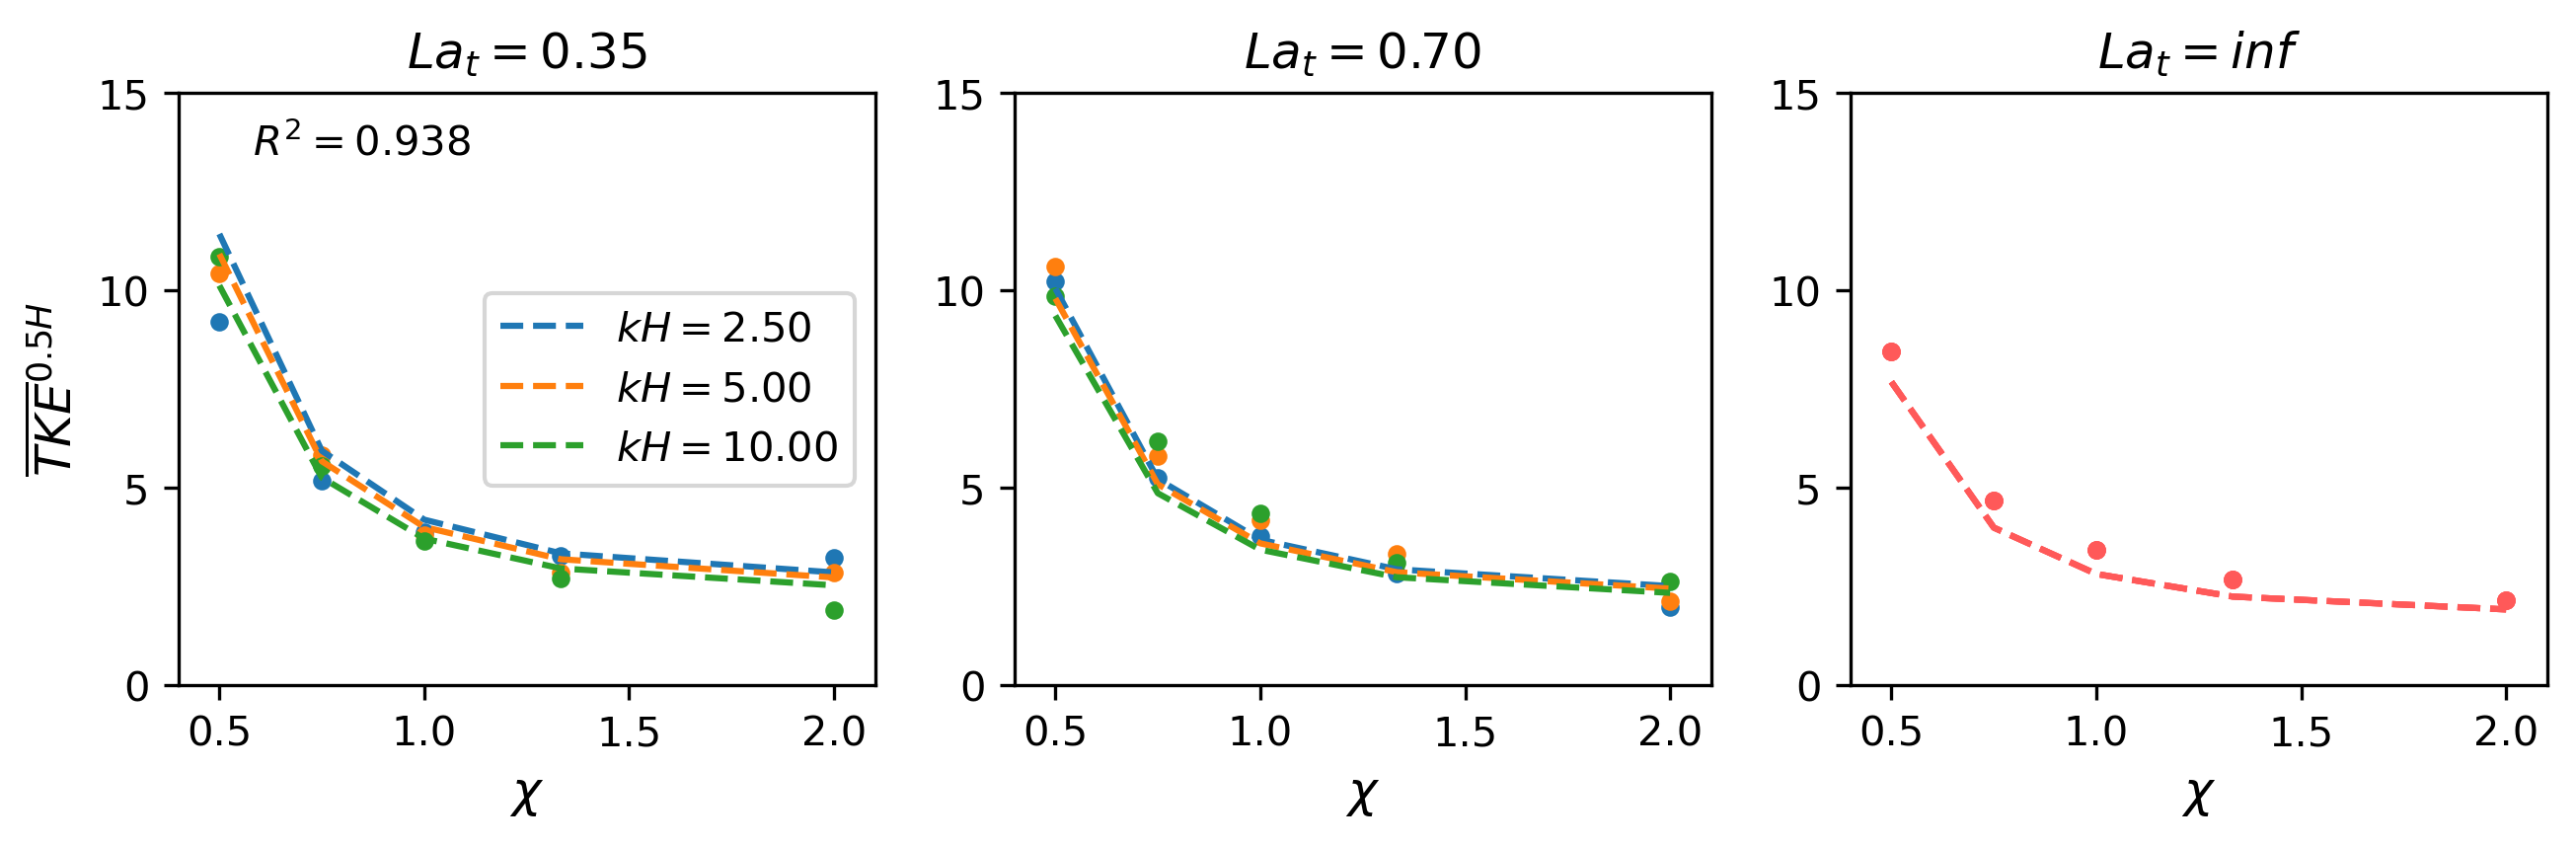

In [84]:
## Show the TKE fitting results for given Laₜ, χ, and kH
# Case range
n_Laₜ = len(Laₜ_all)
n_χ = len(χ_all)
n_kH = len(kH_all)

# Figure parameters
figsize = [10, 6]
param_gs = dict(left=0.1, right=0.90, bottom=0.1, top=0.9, hspace=0.4)
lw = 1.5
ls = '--'
ms = 12
xlim_χ = (0.4, 2.1)
xlim_kH = (2, 11)
ylim = (0,15)

# Initialize figure
ifig = 0
fig = plt.figure(ifig, figsize=figsize,dpi=300)

gs = fig.add_gridspec(2,n_Laₜ)
gs.update(**param_gs)

# For given Laₜ and kH
for il, Laₜ in enumerate(Laₜ_all):
    isub = il
    ax = fig.add_subplot(gs[0,isub])
    ax.set_title("$La_t={Lat:4.2f}$".format(Lat=Laₜ))
    for ik, kH in enumerate(kH_all):    
        xs = cal_xs(np.array(χ_all, dtype=np.float64))
        xl = cal_xl(Laₜ, np.array(χ_all, dtype=np.float64), kH)
        tke32 = coef_tke32[0] * xl
        tke32_les = np.zeros(n_χ)
        for ic, χ in enumerate(χ_all):
            key_case = find_caseKey(Laₜ, χ, kH)
            tke32_les[ic] = case_all[key_case].data['tke32+']

        if il==2:
            ax.plot(χ_all, tke32**(2/3), color="#ff5959", lw=lw, ls=ls,
            label="$kH=NaN$")
            ax.set_ylim(ylim)
            ax.set_yticks([0,5,10,15])
        else:
            ax.plot(χ_all, tke32**(2/3), color="C{:02d}".format(ik), lw=lw, ls=ls,
            label="$kH={:4.2f}$".format(float(kH)))
            ax.set_yticks([0,5,10,15])
        if il==2:
            ax.scatter(χ_all, tke32_les**(2/3), s=ms, color="#ff5959")
        else:
            ax.scatter(χ_all, tke32_les**(2/3), s=ms, color="C{:02d}".format(ik))
            
        ax.set_xlim(xlim_χ)
        ax.set_ylim(ylim)
        ax.set_xlabel("$\chi$",fontsize=12)
        if isub==0:
            ax.set_ylabel("${\overline{TKE}^{0.5H}}$",fontsize=12)
    if isub == 0:
        ax.legend(loc="center right")
        ax.text(0.42, 0.95, "$R^2={:5.3f}$".format(R2_tke32),
            transform=ax.transAxes, ha='right', va='top')


# # For given Laₜ and χ
# for il, Laₜ in enumerate(Laₜ_all):
#     isub = il
#     ax = fig.add_subplot(gs[isub, 1])
#     ax.set_title("${\overline{tke}^H}^{3/2}$, "+"$La_t={Lat:4.2f}$".format(Lat=Laₜ))
#     for ic, χ in enumerate(χ_all):
#         xs = cal_xs(χ) * np.ones(n_kH)
#         xl = np.zeros(n_kH) + cal_xl(Laₜ, χ, np.array(kH_all, dtype=np.float64))
#         tke32 = coef_tke32[0] * xl
#         tke32_les = np.zeros(n_kH)
#         for ik, kH in enumerate(kH_all):
#             key_case = find_caseKey(Laₜ, χ, kH)
#             tke32_les[ik] = case_all[key_case].data['tke32+']
#         ax.plot(kH_all, tke32, color="C{:02d}".format(ic), lw=lw, ls=ls,
#             label="$\chi={:4.2f}$".format(float(χ)))
#         ax.scatter(kH_all, tke32_les, s=ms, color="C{:02d}".format(ic))
#         ax.set_xlim(xlim_kH)
#         ax.set_ylim(ymin=0)
#         ax.set_xlabel("$kH$")
#     if isub == 0:
#         ax.legend(loc="upper right")
fig.savefig("tke_newmodel_05H",bbox_inches='tight')
plt.show()

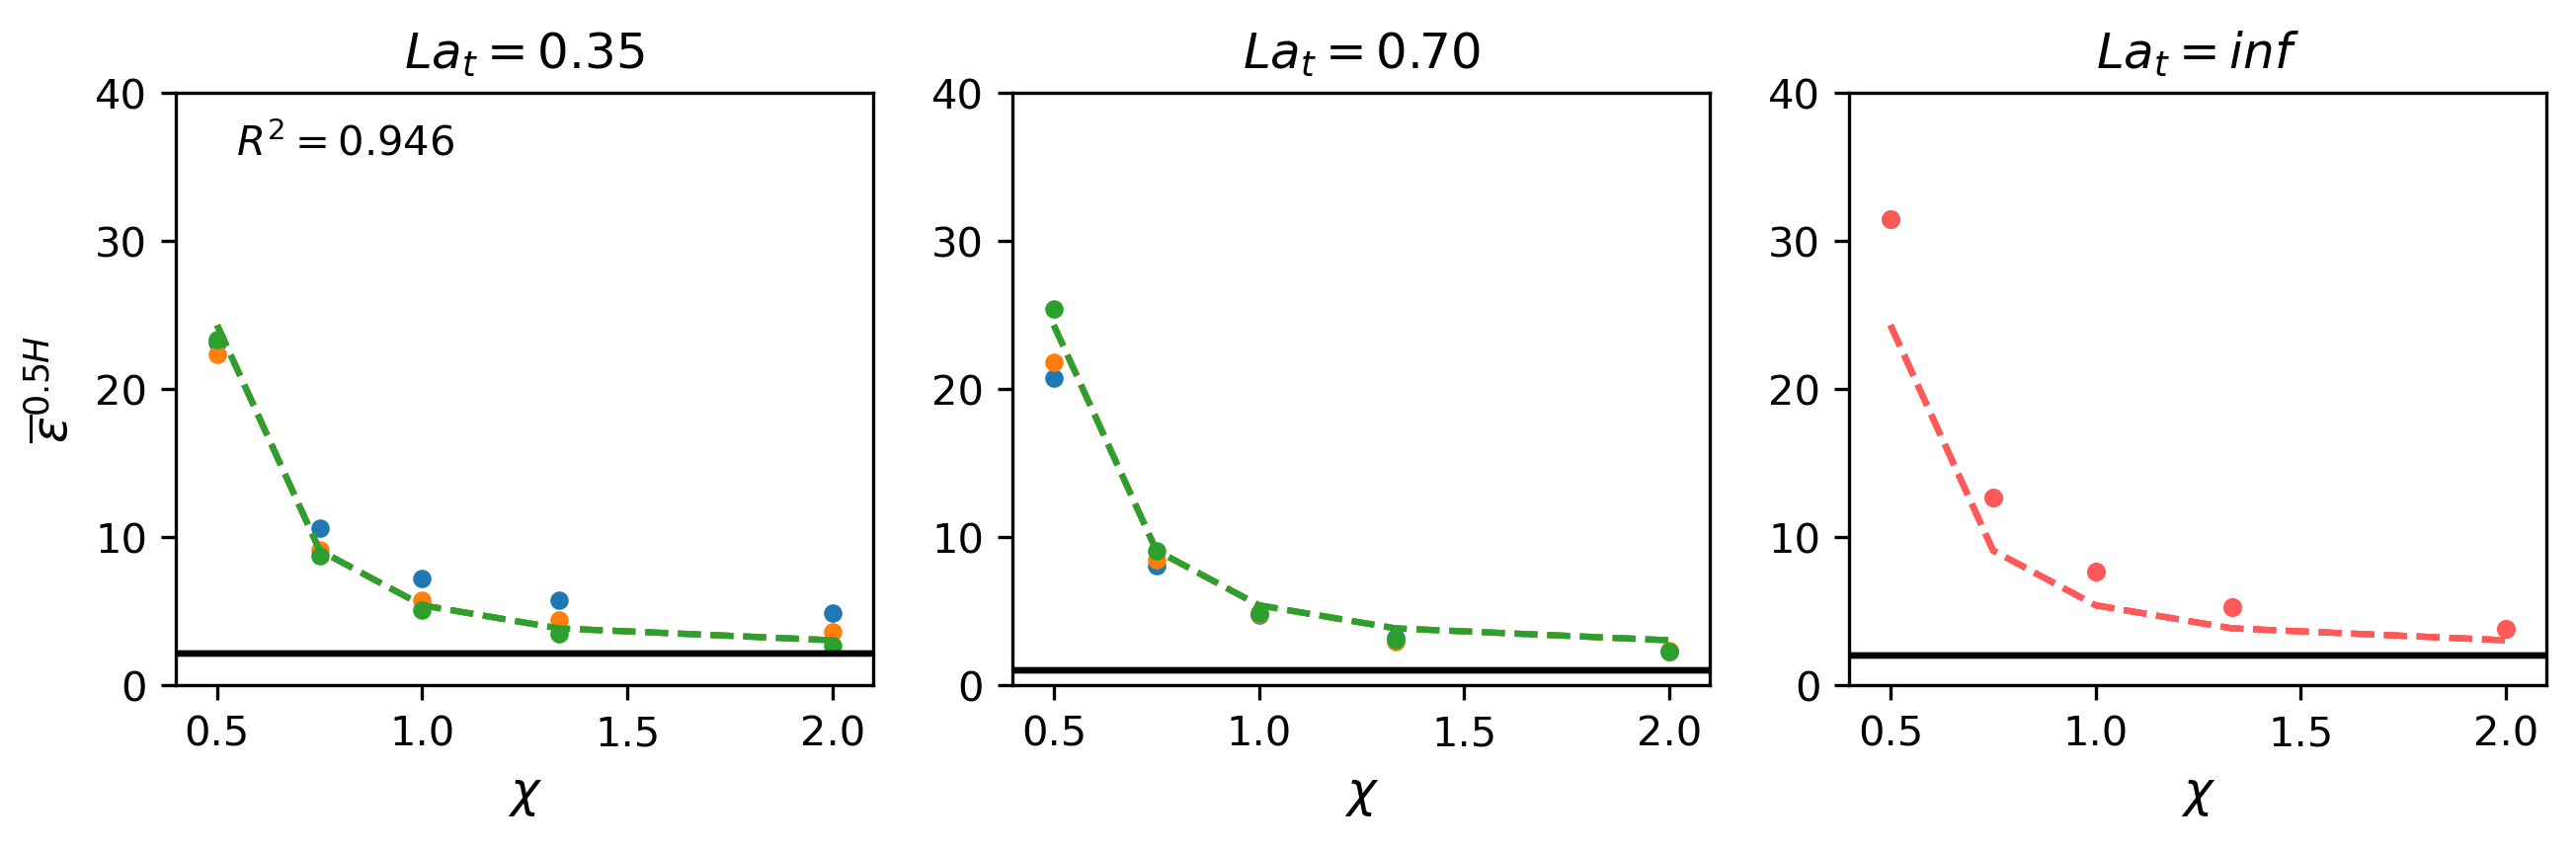

In [33]:
## Show the dissipation fitting results for given Laₜ, χ, and kH
# Case range
n_Laₜ = len(Laₜ_all)
n_χ = len(χ_all)
n_kH = len(kH_all)

# Figure parameters
figsize = [10, 6]
param_gs = dict(left=0.1, right=0.90, bottom=0.1, top=0.9, hspace=0.4)
lw = 1.5
ls = '--'
ms = 12
xlim_χ = (0.4, 2.1)
xlim_kH = (2, 11)
ylim = (0, 40)

# Initialize figure
ifig = 0
fig = plt.figure(ifig, figsize=figsize,dpi=300)

gs = fig.add_gridspec(2,n_Laₜ)
gs.update(**param_gs)

# For given Laₜ and kH
for il, Laₜ in enumerate(Laₜ_all):
    isub = il
    ax = fig.add_subplot(gs[0,isub])
    ax.set_title("$La_t={Lat:4.2f}$".format(Lat=Laₜ))
    for ik, kH in enumerate(kH_all):    
        xs = cal_xs(np.array(χ_all, dtype=np.float64))
        xl = cal_xl(Laₜ, np.array(χ_all, dtype=np.float64), kH)
        dissip = coef_dissip[0] * xs
        dissip_les = np.zeros(n_χ)
        for ic, χ in enumerate(χ_all):
            key_case = find_caseKey(Laₜ, χ, kH)
            dissip_les[ic] = case_all[key_case].data['dissip+']
        if il==2:
            ax.plot(χ_all, dissip, color="#ff5959", lw=lw, ls=ls,
            label="$kH=NaN$")
            ax.axhline(y=2, color="k", lw=lw, ls='-',
            label="$Belcher (2012)$")
        else:
            ax.plot(χ_all, dissip, color="C{:02d}".format(ik), lw=lw, ls=ls,
            label="$kH={:4.2f}$".format(float(kH)))
            As=2*(1-np.exp((-1/2)*Laₜ))
            AL=0.22
            ax.axhline(y=As+AL*Laₜ**(-2), color="k", lw=lw, ls='-',
            label="$Belcher (2012)$")

        if il==2:
            ax.scatter(χ_all, dissip_les, s=ms, color="#ff5959")
        else:
            ax.scatter(χ_all, dissip_les, s=ms, color="C{:02d}".format(ik))
        ax.set_xlim(xlim_χ)
        ax.set_ylim(ylim)
        ax.set_xlabel("$\chi$",fontsize=12)
        if isub==0:
            ax.set_ylabel("${\overline{\epsilon}}^{0.5H}$",fontsize=12)
    if isub == 0:
        # ax.legend(loc="center right")
        ax.text(0.4, 0.95, "$R^2={:5.3f}$".format(R2_dissip),
            transform=ax.transAxes, ha='right', va='top')

# # For given Laₜ and χ
# for il, Laₜ in enumerate(Laₜ_all):
#     isub = il
#     ax = fig.add_subplot(gs[isub, 1])
#     ax.set_title("$\overline{\epsilon}^{0.5H}$"+"$La_t={Lat:4.2f}$".format(Lat=Laₜ))
#     for ic, χ in enumerate(χ_all):
#         xs = cal_xs(χ) * np.ones(n_kH)
#         xl = cal_xl(Laₜ, χ, np.array(kH_all, dtype=np.float64))
#         dissip = coef_dissip[0] * xs
#         dissip_les = np.zeros(n_kH)
#         for ik, kH in enumerate(kH_all):
#             key_case = find_caseKey(Laₜ, χ, kH)
#             dissip_les[ik] = case_all[key_case].data['dissip+']
#         ax.plot(kH_all, dissip, color="C{:02d}".format(ic), lw=lw, ls=ls,
#             label="$\chi={:4.2f}$".format(float(χ)))
#         ax.scatter(kH_all, dissip_les, s=ms, color="C{:02d}".format(ic))
#         ax.set_xlim(xlim_kH)
#         ax.set_ylim(ymin=0)
#         ax.set_xlabel("$kH$")
#     if isub == 0:
#         ax.legend(loc="upper right")
fig.savefig("dissip_newmodel_05H",bbox_inches='tight')
plt.show()

# new scale & belcher2012

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8092\3404878651.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dissip_fit[il] = coef_dissip[0] * xs
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8092\3404878651.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dissip_fit[il] = coef_dissip[0] * xs
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8092\3404878651.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dissip_fit[il] = coef_dissip[0] 

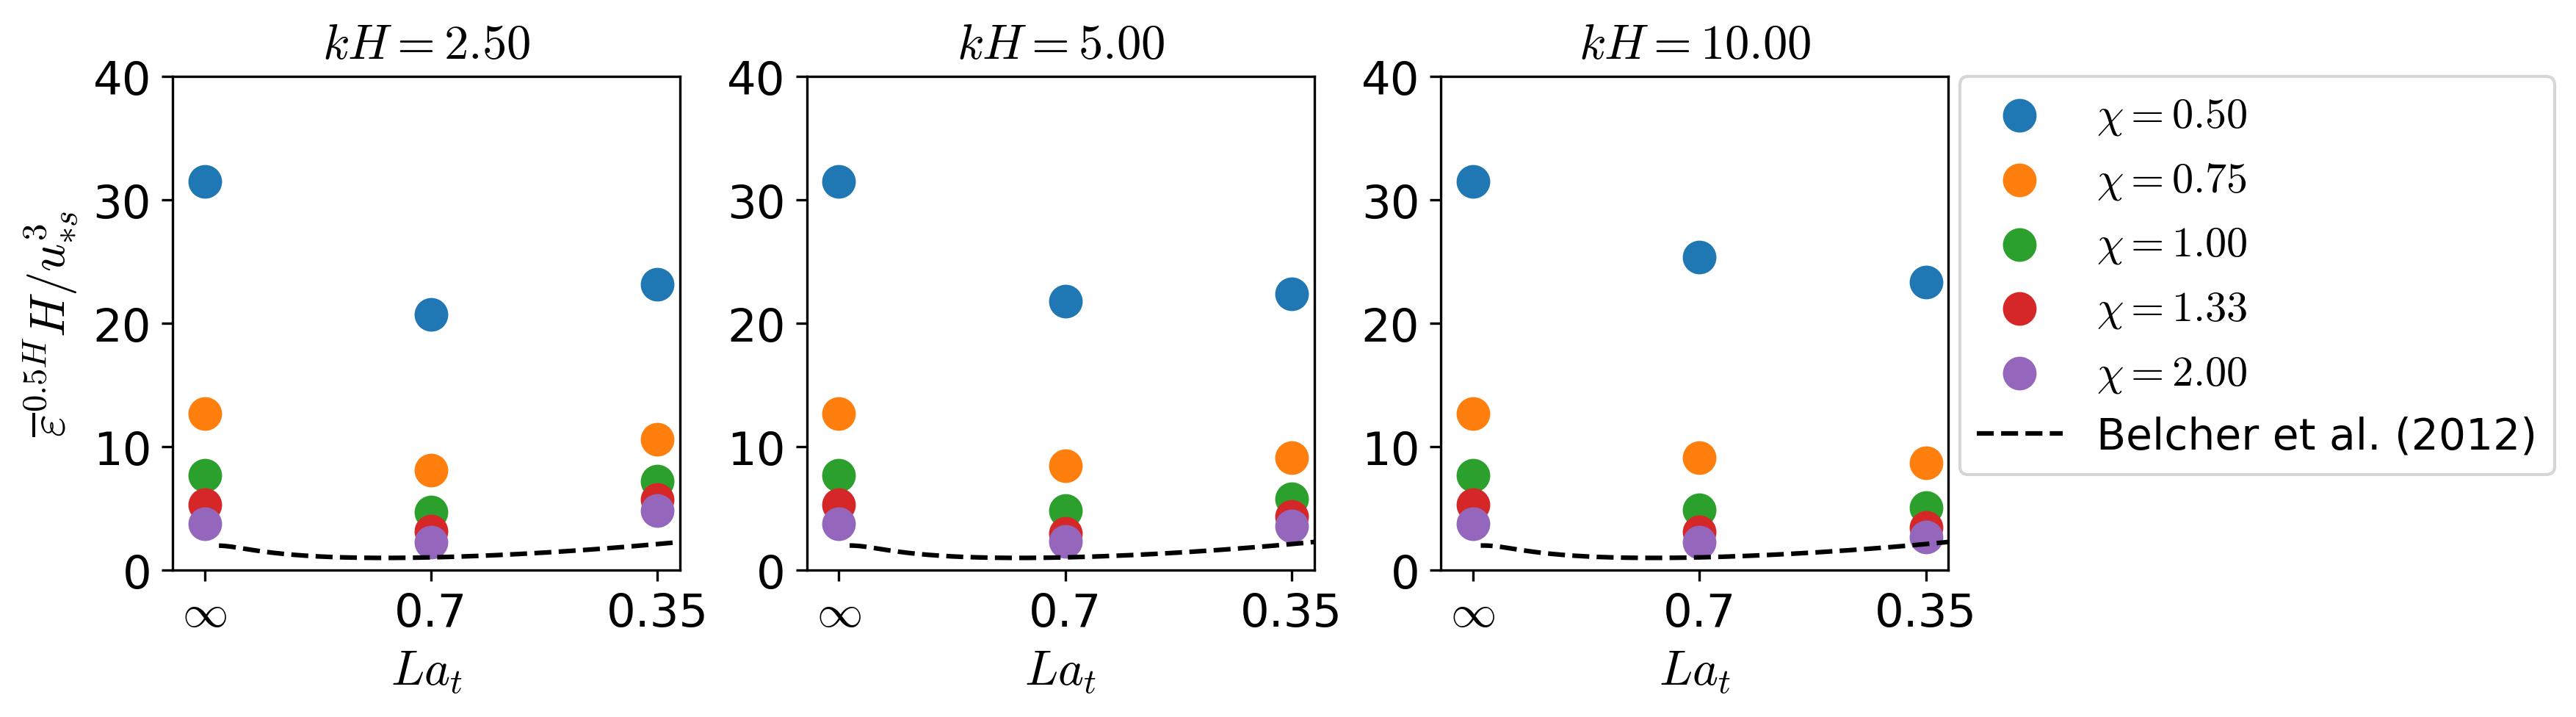

In [29]:
plt.rcParams['mathtext.fontset'] = 'cm'
# Show the TKE fitting results for given χ, kH, and Laₜ as x-axis
# Case range
n_Laₜ = len(Laₜ_all)
n_χ = len(χ_all)
n_kH = len(kH_all)

# Figure parameters
figsize = [12.4, 2.8]  # 加大了高度以适应 3 行子图
param_gs = dict(left=0.1, right=0.750, bottom=0.1, top=0.9, hspace=0.2, wspace=0.25)
lw = 1.5
ls = '--'
ms = 100
xlim_Laₜ = (-0.2, 3)  # 设置Laₜ的x轴范围
ylim = (0, 40)

# Initialize figure
ifig = 0
fig = plt.figure(ifig, figsize=figsize, dpi=300)

# 创建网格布局，行数为3，列数为kH的数量
gs = fig.add_gridspec(1, n_kH)
gs.update(**param_gs)

# 对于每个kH创建一列子图（包含3行）
for ik, kH in enumerate(kH_all):
    # 初始化三行子图
    ax1 = fig.add_subplot(gs[0, ik])
    
    # 第一行设置标题
    ax1.set_title("$kH={:4.2f}$".format(float(kH)),fontsize=16)
    
    # 对于每个χ值
    for ic, χ in enumerate(χ_all):
        dissip_les = np.zeros(n_Laₜ)
        dissip_fit = np.zeros(n_Laₜ)
        tke32_les_H = np.zeros(n_Laₜ)
        nu_t_les = np.zeros(n_Laₜ)
        new_scale = (1 + 1/(χ**3))**(1/3)
        
        # 对于每个Laₜ值
        for il, Laₜ in enumerate(Laₜ_all):
            # 计算拟合值
            xs = cal_xs(np.array([χ], dtype=np.float64))
            xl = cal_xl(Laₜ, np.array([χ], dtype=np.float64), kH)
            dissip_fit[il] = coef_dissip[0] * xs
            
            # 获取LES数据
            key_case = find_caseKey(Laₜ, χ, kH)
            
            # 提取三种不同的数据
            dissip_les[il] = case_all[key_case].data['dissip+'] 
            tke32_les_H[il] = case_all[key_case].data['tke32+_les_H']
            nu_t_les[il] = 0.09 * case_all[key_case].data['tke2+_nut'] / case_all[key_case].data['dissip+_nut']

        # 在最左侧子图设置 y 轴标签
        if kH == 2.5: # 假设 2.5 是第一个 kH，或者你可以改成 if ik == 0:
            ax1.set_ylabel(r"${\overline{\varepsilon}}^{0.5H}H/u_{*s}^3$", fontsize=16)
        
        # 定义统一的 x 轴坐标
        x_vals = tuple(1/x for x in Laₜ_all)

        # 分别在三行中绘制散点图
        ax1.scatter(x_vals, dissip_les, s=ms, color="C{:02d}".format(ic), label="$\chi={:4.2f}$".format(float(χ)))
    
    # 为每一行的子图统一设置 x 轴格式
    for ax in [ax1]:
        ax.set_xlim(xlim_Laₜ)
        ax.set_xticks(tuple(1/x for x in Laₜ_all))
        ax.set_xticklabels(['0.35', '0.7', '$\infty$'])
        ax.tick_params(axis='both', which='major', labelsize=15)
        
    ax1.set_ylim(ylim) # 原代码的 ylim (0,6) 仅作用于第一行。如果后面两行也需要固定 y轴范围，可类似设置 ax2.set_ylim(...)
    # 仅在最底下一行(ax3)显示 x 轴标签
    ax1.set_xlabel("$La_t$", fontsize=16)

    # 计算理论拟合曲线 (Belcher et al.) - 仅在第一行绘制
    # 这里 Lat 起点设为 1e-5 以避免 1/Lat 出现除以 0 的警告
    Lat = np.linspace(1e-5, 20, 1000) 
    As = 2 * (1 - np.exp((-1/2)*Lat))
    AL = 0.22
    epsilon = As + AL * Lat**(-2)
    
    if ik == 2: # 最右侧子图添加 legend
        ax1.plot(1/Lat, epsilon, color='k', lw=lw, ls=ls, label="Belcher et al. (2012)")
        ax1.legend(bbox_to_anchor=(0.98, 0.15),fontsize=14)
    else:
        ax1.plot(1/Lat, epsilon, color='k', lw=lw, ls=ls)

fig.savefig("epsilon_les_oldscale_05H_belcher", bbox_inches='tight')
plt.show()